In [139]:
using Distributions
using StatsBase
using PythonPlot
using DataFrames
using Optim
using NLsolve
using Setfield
using CSV
using Turing
using LinearAlgebra
include("simulations.jl")
include("estimators.jl")
include("models.jl")
include("rem_theory.jl")

FIG_PATH = "/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

"/Users/elevien/Dropbox (Dartmouth College)/Apps/Overleaf/Finite Lineages Plos Journal/paper/figures"

# setup

## Load data

In [166]:
# Read CSV file
data = CSV.read("/Users/elevien/Downloads/experimental_data/cell_list_25C.csv", DataFrame)

L = length(data[data.lineage .== 1,:lineage])
M = length(unique(data.lineage))
data[:,:n] = vcat([collect(1:L) for i in 1:M]...)
data[:,:t] = data[:,:birth_time]

gt = []
for i in unique(data.lineage)
    gti = diff(data[data.lineage .== i,:t])
    push!(gt,vcat(gti,gti[end]))
end
gt = vcat(gt...)
data[:,:gt] = gt;
μ = mean(data[:,:gt])
data[:,:gt] = data[:,:gt]
data[:,:t] = (data[:,:t] .-1);

## Fitting functions

Note: Move to .jl file

In [167]:
function fitar(y)
    L = length(y[:,1])
    X = hcat(ones(L-1),y[1:L-1,:])
    b = X\y[2:end,:]
    v = mean((y[2:end,:] .- X*b).^2,dims=1)'
    return θ = (b = b,v = v)
end

function runar(y0,θ,n)
    n_vars = length(y0)
    yp = zeros((n,n_vars))
    yp[1,:] = y0
    for k in 2:n
        yp[k,:] = θ.b' * vcat(1,yp[k-1,:]) .+ rand(MvNormal(zeros(n_vars),diagm(θ.v[:,1])))
    end
    return yp
end

runar (generic function with 1 method)

# Fitting

## Fit autoregressive mode

In [168]:

y = Matrix(data[data.lineage .== 50,[:gt]]);
L = length(y[:,1])
M = 70
θ_fit = fitar(y);
times = runar(y[1,:],θ_fit,L*M);
n = vcat([collect(1:L) for k in 1:M]...);
lineages = vcat([ones(L)*k for k in 1:M]...);
ar1 = DataFrame((lineage=lineages,gt = times[:,1],t=cumsum( times[:,1]),n=n));
ar1.t = vcat([ar1[ar1.lineage .==l,:t] .- ar1[ar1.lineage .==l,:t][1] for l in unique(ar1.lineage)]...);

#θ_fit = @set θ_fit.b[2,1] = 0;
ar1
CSV.write("./output/ar1_fitted.csv",ar1)

"./output/ar1_fitted.csv"

## Fit cell-size control model (WIP)

# Plot Trajectories

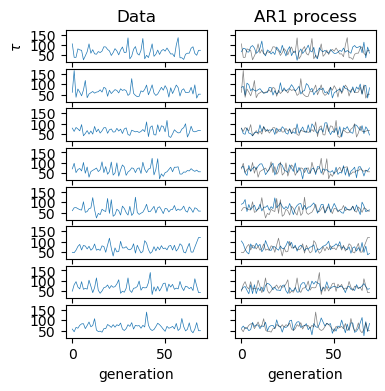

In [170]:
nrows = 8
fig, axs= subplots(figsize=(4,4),ncols = 2,nrows=nrows,sharex=true,sharey=true)

for l in  1:nrows
    ax = axs[l-1,1]
    ax.plot(ar1[ar1.lineage .== l,:gt],"-",lw=0.5)
    ax.plot(data[data.lineage .== l,:gt],"k-",alpha=0.5,lw=0.5)

    ax = axs[l-1,0]
    ax.plot(data[data.lineage .== l,:gt],"-",lw=0.5)
end
axs[0,0].set_title("Data")
axs[0,0].set_ylabel(L"$\tau$")
axs[-1,0].set_xlabel("generation")
axs[-1,1].set_xlabel("generation")
axs[0,1].set_title("AR1 process")
fig

# Plot estimate vs. alpha

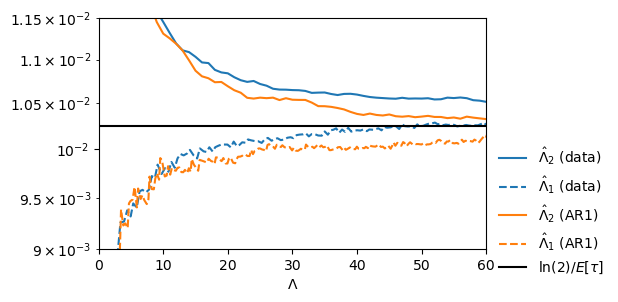

In [171]:
fig, ax= subplots(figsize=(5,3))
n_range = 1:1:70
t_range =  sort(unique(data.t))[1:20:end]

# data -----------------------------------------------------------------
ax.plot(n_range,[FDE(data[data.n .== k,:t],k) for k in n_range],"C0-",label=L"$\hat{\Lambda}_2$ (data)")

N = [[(length(data[(data.lineage .== l) .& (data.t .< t),:n]) -1) for l in unique(data.lineage)] for t in t_range]
ax.plot(t_range ./ mean(data.gt),FTE.(N,t_range),"C0--",label=L"$\hat{\Lambda}_1$ (data)")

# ar1 -----------------------------------------------------------------
t_range =  sort(unique(ar1.t))[1:20:end]
ax.plot(n_range,[FDE(ar1[ar1.n .== k,:t],k) for k in n_range],"C1-",label=L"$\hat{\Lambda}_2$ (AR1)")

N = [[(length(ar1[(ar1.lineage .== l) .& (ar1.t .< t),:n]) -1) for l in unique(ar1.lineage)] for t in t_range]
ax.plot(t_range ./ mean(ar1.gt),FTE.(N,t_range),"C1--",label=L"$\hat{\Lambda}_1$ (AR1)")


ax.semilogy(t_range ./ mean(data.gt), log(2)*ones(length(t_range)) ./ mean(data.gt) ,"k-",label=L"$\ln(2)/E[\tau]$")
ax.set_ylim([0.009,0.0115])
ax.set_xlim([0,60])
ax.set_xlabel(L"$t/\tau_0$")
ax.set_xlabel(L"$\Lambda$")
ax.legend(frameon=false,bbox_to_anchor=(1, 0.5))
savefig(FIG_PATH*"/data_vs_ar1_convergence.pdf",bbox_inches="tight")
fig

In [103]:
θ_fit

(b = [71.63144100368156; -0.028269391275931893;;], v = [296.2596515333927;;])

In [13]:
fig, ax= subplots(figsize=(4,2))
n_range = 1:5:70
t_range =  sort(unique(data.t))[1:100:end]
ax.plot(n_range,[FDE(data[data.n .== k,:t],k) for k in n_range])

N = [[(length(data[(data.lineage .== l) .& (data.t .< t),:n]) -1) for l in unique(data.lineage)] for t in t_range]
ax.plot(t_range ./ mean(data.gt),FTE.(N,t_range),".")
ax.plot(t_range ./ mean(data.gt), log(2)*ones(length(t_range)) ./ mean(data.gt) ,label=L"$\ln(2)/E[\tau]$")

t_range =  sort(unique(ar1.t))[1:100:end]
ax.plot(n_range,[FDE(ar1[ar1.n .== k,:t],k) for k in n_range])

N = [[(length(ar1[(ar1.lineage .== l) .& (ar1.t .< t),:n]) -1) for l in unique(ar1.lineage)] for t in t_range]
ax.plot(t_range ./ mean(ar1.gt),FTE.(N,t_range),".")
ax.plot(t_range ./ mean(ar1.gt),ones(length(t_range)).*Ltrue ./ mean(ar1.gt),"-")
ax.set_ylim([Ltrue./ mean(ar1.gt)  .- 0.0008,Ltrue ./ mean(ar1.gt) .+ .0008])
fig

NLsolve.IsFiniteException: During the resolution of the non-linear system, the evaluation of the following equation(s) resulted in a non-finite number: [1]

# Check scaling of variance

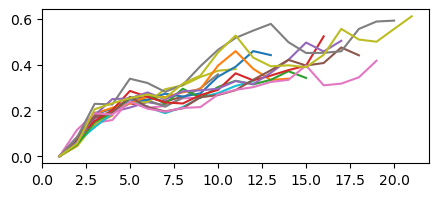

In [37]:
step = 500
data[:,:t_round] = round.(data.t / step) * step;

fig,ax = subplots(figsize=(5,2))

for g in 2:20
    # ------------------------------------------------------------
    Xg = grouplineages(data,g)
     
    v = combine(groupby(Xg,:n),:t => var => :v).v
    m = combine(groupby(Xg,:n),:t => mean => :m).m

    des = hcat(ones(length(m)),collect(1:length(m)))
    b = des\m
    y_fit = des*b 

    ax.plot(1:length(m),v,"-")
end
#
fig

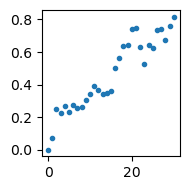

In [40]:
fig,ax = subplots(figsize=(2,2))
ax.plot(combine(groupby(grouplineages(data,30),:n),:t => var => :v).v,".")
tight_layout()
fig


It look slike the variance is not increasing linearly with time as we expect (show simulations in comparison)